In [25]:
# importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,RandomizedSearchCV,cross_val_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier,GradientBoostingClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score
import warnings
import pickle


In [ ]:
# Load Dataset
df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\creditcard.csv")
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [3]:
 df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

C:\Users\HP\AppData\Local\Temp\ipykernel_9624\1917527504.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Class",data=df,palette="Set2")


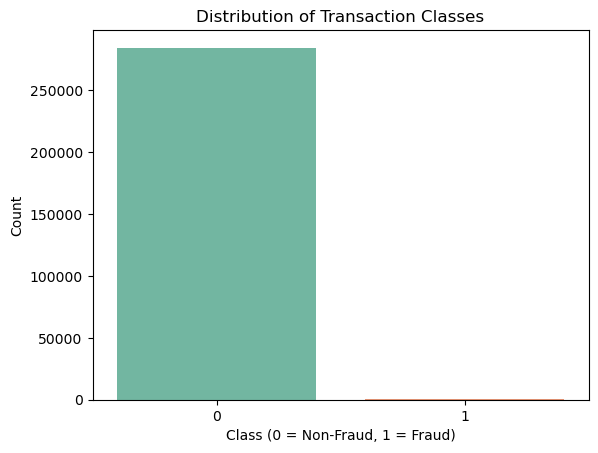

In [8]:
sns.countplot(x="Class",data=df,palette="Set2")
plt.title("Distribution of Transaction Classes")
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

In [ ]:
# Select Feature and Target
x = df.drop(["Class","Time"],axis=1)
y = df["Class"]

In [ ]:
# Scaling of Data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x["Amount"] = scaler.fit_transform(x[["Amount"]])

In [ ]:
# Split Train and Test Data
from sklearn.model_selection import train_test_split,cross_val_score,RandomizedSearchCV,StratifiedKFold
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
# Handle Class Imbalance
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
x_res,y_res = sm.fit_resample(x_train,y_train)

In [13]:
# Cross Validation
sk = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [14]:
# Model 1:- XGBoost
xgb = XGBClassifier(random_state=42,eval_metric="logloss",use_label_encoder=False)
param_grid = {
    "n_estimators":[100,150,200],
    "max_depth":[3,4,5],
    "learning_rate":[0.1,0.01,0.5,0.05],
    "colsample_bytree":[0.6,0.7,0.8,0.9],
    "subsample":[0.6,0.7,0.8,0.9],
    "gamma":[0.6,0.7,0.8,0.9],
    "reg_lambda":[1,2,3],
    "reg_alpha":[0.8,1]
}
grid_xgb = RandomizedSearchCV(xgb,param_grid,cv=sk,n_jobs=-1,scoring="roc_auc",
n_iter=20,random_state=42)
grid_xgb.fit(x_res,y_res)
print(grid_xgb.best_score_)
best_xgb = grid_xgb.best_estimator_

c:\Users\HP\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:41:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


0.999987205742762


In [15]:
# Model 2:- Lightlgb
lgb = LGBMClassifier(random_state=42,verbose=0)
param_grid = {
    "max_depth":[2,3,4,5],
    "n_estimators":[100,150,200],
    "learning_rate":[0.1,0.01,0.5,0.05]
}
grid_lgb = RandomizedSearchCV(lgb,param_grid,cv=sk,n_iter=20,scoring="roc_auc",n_jobs=-1,random_state=42)
grid_lgb.fit(x_res,y_res)
print(grid_lgb.best_score_)
best_lgb = grid_lgb.best_estimator_

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [18]:
# Model 3:- Logistic Regression(Meta Model)
lr = LogisticRegression(random_state=42,class_weight="balanced")
param_grid = {
    "max_iter":[500,1000],
    "C":[0.1,0.4]
}
grid_lr = RandomizedSearchCV(lr,param_grid,cv=sk,n_jobs=-1,scoring="roc_auc",
n_iter=20,random_state=42)
grid_lr.fit(x_train,y_train)
best_lr = grid_lr.best_estimator_

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=20. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [19]:
# Build Stacking Model
base_model = [
    ("xgb",best_xgb),
    ("lgb",best_lgb)

]
meta_model = best_lr
stack = StackingClassifier(estimators=base_model,final_estimator=meta_model,passthrough=True,cv=5,n_jobs=-1)
stack.fit(x_res,y_res)


StackingClassifier(cv=5,
                   estimators=[('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=0.8, device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logloss',
                                              feature_types=None,
                                              feature_weights=None, gamma=0.7,
                                              grow_policy=None,
                                              importance_type=None,
                                              interacti...
                                              max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=150, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('lgb',
                                LGBMClassifier(max_depth=4, n_estimators=200,
                                               random_state=42, verbose=0))],
                   final_estimator=LogisticRegression(C=0.4,
                                                      class_weight='balanced',
                                                      max_iter=500,
                                                      random_state=42),
                   n_jobs=-1, passthrough=True)

In [20]:
# Model Evaluation
y_pred = stack.predict(x_test)
y_proba = stack.predict_proba(x_test)[:, 1]
print("\n--- Model Evaluation ---")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))



--- Model Evaluation ---
Test Accuracy: 0.9991
ROC-AUC Score: 0.9447

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.70      0.86      0.77        98

    accuracy                           1.00     56962
   macro avg       0.85      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962



In [21]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[56828    36]
 [   14    84]]


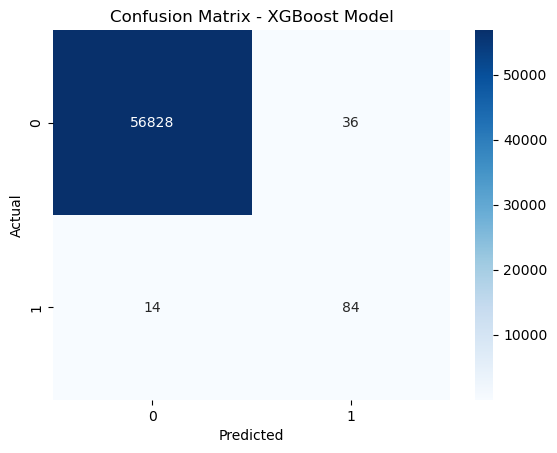

In [22]:
# Confusion Matrix Plot
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost Model")
plt.show()


In [23]:
# Cross Validation
cv_score = cross_val_score(stack, x, y, cv=sk, scoring="roc_auc", n_jobs=-1)
print(f"\nMean Cross-Validation ROC-AUC: {cv_score.mean():.4f}")


Mean Cross-Validation ROC-AUC: 0.9786


C:\Users\HP\AppData\Local\Temp\ipykernel_9624\511920928.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=xgb_importance.head(15), palette='viridis')


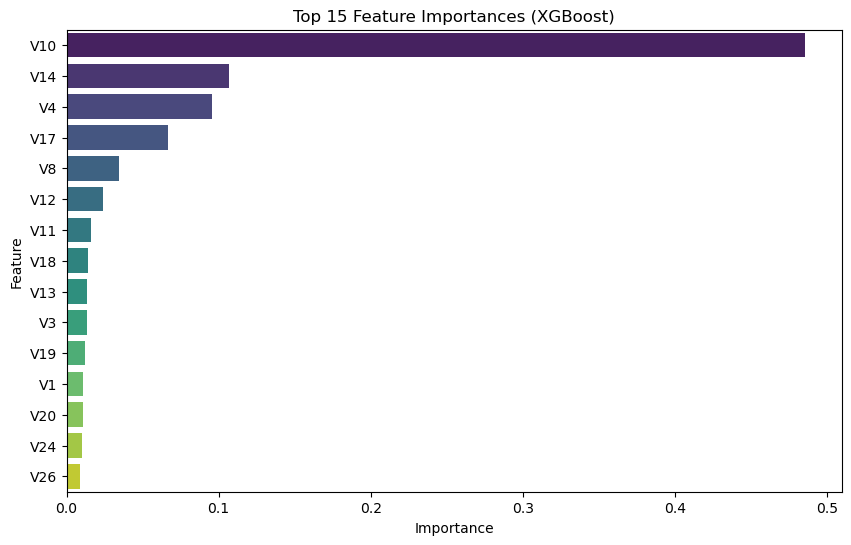

In [27]:
# --- XGBoost Feature Importance ---
xgb_model = best_xgb
xgb_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=xgb_importance.head(15), palette='viridis')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

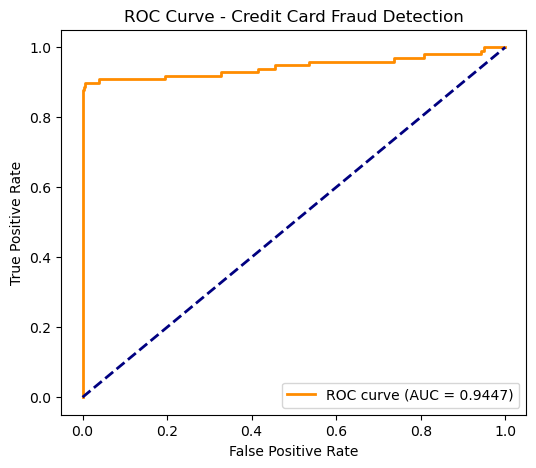

In [28]:
# ROC_AUC curve
from sklearn.metrics import roc_curve, auc

y_proba = stack.predict_proba(x_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Credit Card Fraud Detection')
plt.legend(loc="lower right")
plt.show()

In [29]:
fraud = "Fraud.sav"
pickle.dump(stack,open(fraud,"wb"))

In [ ]:
input_data = ([[]])
prediction = fraud.predict(input_data)
prediction